# **2026 FIFA World Cup Winner Prediction Model**


This notebook builds a model that predicts the outcome of World Cup matches.

Pipeline:
1. Load World Cup match history and qualifiers, plus Elo ratings
2. Build a time aware dynamic Elo rating with no data leakage, capturing team trajectories
3. Add rolling form features from the last 5 matches
4. Tune tournament weights via walk forward cross validation
5. Compare three models with walk forward CV: Logistic Regression, Random Forest, XGBoost
6. Train the final model on all available historical data with the tuned weights
7. Define predict_match() to predict the outcome between any two teams
8. Simulate the bracket with a Numba accelerated Monte Carlo method
9. Print the projected results from the Round of 32 through to the Final


### 1. Imports

In [50]:
import pandas as pd
import numpy as np
import warnings, itertools, time
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report
from xgboost import XGBClassifier

from numba import njit

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick


### 2. Loading Data

In [51]:
ELO_FILE = '/content/Football Elo Ratings.xlsx'
WC_FILE  = '/content/World Cup matches.xlsx'

elo_raw = pd.read_excel(ELO_FILE)
wc2014  = pd.read_excel(WC_FILE, sheet_name='WorldCup2014')
wc2018  = pd.read_excel(WC_FILE, sheet_name='WorldCup2018')
wc2022  = pd.read_excel(WC_FILE, sheet_name='WorldCup2022')
wc2026  = pd.read_excel(WC_FILE, sheet_name='WorldCup2026')
qual    = pd.read_excel(WC_FILE, sheet_name='WorldCup2026Qualifiers')

for df, name in [(wc2014,'WC2014'),(wc2018,'WC2018'),(wc2022,'WC2022'), (wc2026,'WC2026'),(qual,'QUAL')]:
    df['tournament'] = name

print(f"ELO table : {len(elo_raw)} teams")
for df, name in [(wc2018,'WC2018'),(wc2022,'WC2022'),(wc2026,'WC2026'),(qual,'QUAL')]:
    print(f"{name:<10}: {len(df):>4} matches")


ELO table : 242 teams
WC2018    :   64 matches
WC2022    :   64 matches
WC2026    :   66 matches
QUAL      :  889 matches


### 3. Cleaning the Elo Table

In [52]:
elo = elo_raw.rename(columns={
    'Rank':'rank','Team':'team','Rating':'elo',
    'Average Rank':'avg_rank','Average Rating':'elo_1yr_ago',
    '1 Year Change Average Rank':'rank_chg_1yr',
    '1 Year Change Average Rating':'rating_chg_1yr',
    'Matches Total':'total_matches','Matches Home':'home_matches',
    'Matches Away':'away_matches','Matches Neutral':'neutral_matches',
    'Matches Wins':'wins','Matches Losses':'losses',
})

# Some rows have two teams joined by a newline (merged cells in the source Excel file),
# so these need to be split back into separate rows

fixed_rows = []
for _, row in elo.iterrows():
    if '\n' in str(row['team']):
        parts = {col: str(row[col]).split('\n') for col in elo.columns}
        n = len(parts['team'])
        for i in range(n):
            new_row = {col: parts[col][i] if i < len(parts[col]) else None
                       for col in elo.columns}
            fixed_rows.append(new_row)
    else:
        fixed_rows.append(row.to_dict())
elo = pd.DataFrame(fixed_rows).reset_index(drop=True)

# converting numeric columns which are in text from the xlsx file
num_cols = ['rank','elo','avg_rank','elo_1yr_ago','rank_chg_1yr','rating_chg_1yr',
            'total_matches','home_matches','away_matches','neutral_matches','wins','losses']
for col in num_cols:
    elo[col] = pd.to_numeric(elo[col], errors='coerce')
elo = elo.dropna(subset=['team','elo','total_matches']).reset_index(drop=True)

elo['draws']          = elo['total_matches'] - elo['wins'] - elo['losses']
elo['elo_change_1yr'] = elo['elo'] - elo['elo_1yr_ago']
elo['win_rate']       = (elo['wins']   / elo['total_matches']).round(4)
elo['loss_rate']      = (elo['losses'] / elo['total_matches']).round(4)
elo['draw_rate']      = (elo['draws']  / elo['total_matches']).round(4)

NAME_MAP = {
    'Bosnia & Herzegovina':'Bosnia and Herzegovina',
    'Curacao':'Curaçao','Czech Republic':'Czechia',
    'D.R. Congo':'DR Congo','USA':'United States',
}
elo_lookup = elo.set_index('team')

print(elo[['rank','team','elo','elo_change_1yr','win_rate']].head(10).to_string(index=False))


 rank        team  elo  elo_change_1yr  win_rate
    1   Argentina 2148             160    0.5521
    2       Spain 2144             198    0.5911
    3      France 2123             328    0.5069
    4     England 2038              55    0.5897
    5      Brazil 2009              11    0.6299
    6    Colombia 2004             383    0.4119
    7    Portugal 1990             193    0.4993
    8 Netherlands 1980             132    0.5160
    9      Norway 1918             295    0.3787
   10     Germany 1916               5    0.5790


### 4. Stacking and Cleaning All Matches

In [53]:
qual = qual[['Competition','Home','Away','Date','HG','AG',
             'HS','AS','HST','AST','HF','AF','HC','AC',
             'HY','AY','HR','AR','tournament']]

all_matches = pd.concat([wc2014,wc2018,wc2022,wc2026,qual], ignore_index=True)
all_matches['Date'] = pd.to_datetime(all_matches['Date'])
all_matches = all_matches.sort_values('Date').reset_index(drop=True)
all_matches['Home'] = all_matches['Home'].replace(NAME_MAP)
all_matches['Away'] = all_matches['Away'].replace(NAME_MAP)

for col in ['HS','AS','HST','AST','HF','AF','HC','AC','HY','AY','HR','AR']:
    all_matches[col] = pd.to_numeric(all_matches[col], errors='coerce')
    all_matches[col] = all_matches[col].fillna(all_matches[col].median())

def get_result(r):
    return 'H' if r.HG > r.AG else ('A' if r.HG < r.AG else 'D')

all_matches['result']     = all_matches.apply(get_result, axis=1)

all_matches['H_shot_acc'] = (all_matches['HST']/all_matches['HS'].replace(0,np.nan)).fillna(0)
all_matches['A_shot_acc'] = (all_matches['AST']/all_matches['AS'].replace(0,np.nan)).fillna(0)

print(f"Total matches: {len(all_matches)}")
print()

tourn_summary = (all_matches[all_matches['tournament'] != 'WC2014']
                    .groupby('tournament')['result'].value_counts()
                    .unstack(fill_value=0)[['H','D','A']])
print(tourn_summary)


Total matches: 1147

result        H    D    A
tournament               
QUAL        403  200  286
WC2018       25   14   25
WC2022       29   15   20
WC2026       35   20   11


### 5. Dynamic Elo Ratings

Every team starts at 1500. The rating updates after each match in chronological order.
The feature stored for a match is each team's rating before that match, so there is
no data leakage. This lets the rating track trajectories over time, such as Morocco
rising, Germany declining, or Norway improving.


In [54]:
K_FACTORS = {'WC2014':50,'WC2018':50,'WC2022':50,'WC2026':50,'QUAL':30}

def expected_score(a, b):
  return 1/(1+10**((b-a)/400))

def margin_mult(gd):
  return np.log(abs(gd)+1)+1

def update_elo(a,b,res,gd,k):
  d = k*margin_mult(gd)*(res-expected_score(a,b))
  return round(a+d,1), round(b-d,1)

dynamic_elo   = {}
pre_match_elo = []

for _, row in all_matches.iterrows():
    h, a = row['Home'], row['Away']
    k    = K_FACTORS.get(row['tournament'], 30)
    he   = dynamic_elo.get(h, 1500)
    ae   = dynamic_elo.get(a, 1500)
    pre_match_elo.append((he, ae))
    res  = 1 if row['HG']>row['AG'] else (0 if row['HG']<row['AG'] else 0.5)
    nh, na = update_elo(he, ae, res, abs(int(row['HG'])-int(row['AG'])), k)
    dynamic_elo[h] = nh
    dynamic_elo[a] = na

all_matches['dyn_elo_home'] = [x[0] for x in pre_match_elo]
all_matches['dyn_elo_away'] = [x[1] for x in pre_match_elo]

# Track rating checkpoints per tournament for a few teams of interest
ckpts = {}
for _, row in all_matches.iterrows():
    t = row['tournament']
    ckpts.setdefault(t, {})
    ckpts[t][row['Home']] = dynamic_elo.get(row['Home'],1500)
    ckpts[t][row['Away']] = dynamic_elo.get(row['Away'],1500)

show = ['Morocco','Germany','Argentina','England','Brazil','Norway','France','Spain']
print(f"{'Team':<20}{'WC2018':>9}{'WC2022':>9}{'WC2026':>9}")
for t in show:
    vals = [ckpts.get(trn,{}).get(t,'N/A') for trn in ['WC2018','WC2022','WC2026']]
    print(f"{t:<20}"+"".join(f"{str(v):>9}" for v in vals))


Team                   WC2018   WC2022   WC2026
Morocco                1723.3   1723.3   1723.3
Germany                1735.3   1735.3   1735.3
Argentina              1828.5   1828.5   1828.5
England                1817.7   1817.7   1817.7
Brazil                 1667.9   1667.9   1667.9
Norway                    N/A      N/A   1746.5
France                 1935.7   1935.7   1935.7
Spain                  1731.7   1731.7   1731.7


### 6. Rolling Form Features (Last 5 Matches)

In [55]:
DEFAULTS_FORM = {'form_win_rate':0.40,'form_goals_scored':1.2,
                 'form_goals_conceded':1.2,'form_shot_acc':0.33,'form_yellows':2.0}

def compute_team_form(matches, n=5):
    hdf = matches[['Date','Home','HG','AG','H_shot_acc','HY']].copy()
    hdf.columns = ['date','team','gf','ga','shot_acc','yellows']
    hdf['win'] = (matches['HG']>matches['AG']).astype(int)
    adf = matches[['Date','Away','AG','HG','A_shot_acc','AY']].copy()
    adf.columns = ['date','team','gf','ga','shot_acc','yellows']
    adf['win'] = (matches['AG']>matches['HG']).astype(int)
    long = pd.concat([hdf,adf]).sort_values('date').reset_index(drop=True)
    form = {}
    for team, grp in long.groupby('team'):
        grp = grp.sort_values('date').reset_index(drop=True)
        for i, row in grp.iterrows():
            past = grp.iloc[max(0,i-n):i]
            form[(team,row['date'])] = DEFAULTS_FORM.copy() if len(past)==0 else {
                'form_win_rate'      : past['win'].mean(),
                'form_goals_scored'  : past['gf'].mean(),
                'form_goals_conceded': past['ga'].mean(),
                'form_shot_acc'      : past['shot_acc'].mean(),
                'form_yellows'       : past['yellows'].mean(),
            }
    return form, long

team_form, form_long = compute_team_form(all_matches)
latest_form_per_team = {}
for team, grp in form_long.groupby('team'):
    last = grp.sort_values('date').iloc[-1]
    latest_form_per_team[team] = team_form.get((team,last['date']), DEFAULTS_FORM)

print(f"Form computed for {len(team_form):,} (team, date) entries")
print(f"Latest form cached for {len(latest_form_per_team)} teams")


Form computed for 2,294 (team, date) entries
Latest form cached for 207 teams


### 7. Building the Feature Matrix

In [56]:
def get_static(team):
    if team in elo_lookup.index:
        r = elo_lookup.loc[team]
        return {'win_rate':r['win_rate'],'draw_rate':r['draw_rate'],'rank':r['rank']}
    return {'win_rate':0.40,'draw_rate':0.25,'rank':100}

def build_row(row):
    h,a,d = row['Home'],row['Away'],row['Date']
    hs,as_ = get_static(h), get_static(a)
    hf = team_form.get((h,d), DEFAULTS_FORM)
    af = team_form.get((a,d), DEFAULTS_FORM)

    return {
        'dyn_elo_diff'      : row['dyn_elo_home']-row['dyn_elo_away'],
        'win_rate_diff'     : hs['win_rate']  - as_['win_rate'],
        'draw_rate_diff'    : hs['draw_rate'] - as_['draw_rate'],
        'rank_diff'         : as_['rank']     - hs['rank'],
        'form_win_rate_diff': hf['form_win_rate']       - af['form_win_rate'],
        'form_gf_diff'      : hf['form_goals_scored']   - af['form_goals_scored'],
        'form_ga_diff'      : hf['form_goals_conceded'] - af['form_goals_conceded'],
        'form_shot_acc_diff': hf['form_shot_acc']       - af['form_shot_acc'],
        'form_yellow_diff'  : hf['form_yellows']        - af['form_yellows'],
    }

X_all         = pd.DataFrame([build_row(r) for _,r in all_matches.iterrows()])
y_all         = all_matches['result'].map({'H':0,'D':1,'A':2})
FEATURE_NAMES = X_all.columns.tolist()

print("Feature matrix:", X_all.shape)

for f in FEATURE_NAMES:
  print(f"  {f}")


Feature matrix: (1147, 9)
  dyn_elo_diff
  win_rate_diff
  draw_rate_diff
  rank_diff
  form_win_rate_diff
  form_gf_diff
  form_ga_diff
  form_shot_acc_diff
  form_yellow_diff


### 8. Weight Tuning via Walk-Forward CV

The training weight for each tournament is not guessed. A grid search is run over
candidate values, and the combination that maximizes walk forward accuracy is kept.
Training happens on one tournament and testing on the next.

Qualifier matches get a fixed weight of 0.4, since they generally involve weaker
opposition than the World Cup itself.


In [57]:
m18   = all_matches['tournament']=='WC2018'
m22   = all_matches['tournament']=='WC2022'
m26   = all_matches['tournament']=='WC2026'
mQual = all_matches['tournament']=='QUAL'

QUAL_W      = 0.5
weight_grid = [0.2, 0.4, 0.6, 0.8, 1.0]

best_avg, best_weights = 0, (1.0, 1.0)
results_grid = []

print(f"{'w_2018':>7} {'R1 acc':>8} {'Avg':>8}")

for w18 in weight_grid:
    round_accs = []

    # Single walk-forward round: train on 2018, test on 2022

    for tr_mask, te_mask in [(m18, m22)]:
        X_tr = X_all[tr_mask].values
        y_tr = y_all[tr_mask].values
        X_te = X_all[te_mask].values
        y_te = y_all[te_mask].values
        w_tr = all_matches[tr_mask]['tournament'].map(
            {'WC2018': w18, 'WC2022': 1.0, 'QUAL': QUAL_W, 'WC2026': 1.0}
        ).values
        scaler = StandardScaler()
        X_tr_s = scaler.fit_transform(X_tr)
        X_te_s = scaler.transform(X_te)
        lr = LogisticRegression(max_iter=1000, C=0.5, random_state=42)
        lr.fit(X_tr_s, y_tr, sample_weight=w_tr)
        acc = lr.score(X_te_s, y_te)
        round_accs.append(acc)

    avg = np.mean(round_accs)
    results_grid.append((w18, round_accs[0], avg))
    print(f"{w18:>7.1f} {round_accs[0]:>8.1%} {avg:>8.1%}")
    if avg > best_avg:
        best_avg = avg
        best_weights = (w18,)

W18 = best_weights[0]
W22 = 1.0
print(f"\nBest weights: WC2018 {W18}, WC2022 {W22}, QUAL {QUAL_W}")
print(f"Best walk-forward accuracy: {best_avg:.1%}")


 w_2018   R1 acc      Avg
    0.2    53.1%    53.1%
    0.4    53.1%    53.1%
    0.6    54.7%    54.7%
    0.8    54.7%    54.7%
    1.0    56.2%    56.2%

Best weights: WC2018 1.0, WC2022 1.0, QUAL 0.5
Best walk-forward accuracy: 56.2%


### 9. Walk-Forward Cross-Validation Across Three Models

Using the tuned weights, three models are compared on the walk forward test.


In [58]:
def make_weights(mask, w18, w22, wq=0.5):
    return all_matches[mask]['tournament'].map(
        {'WC2018': w18, 'WC2022': w22, 'QUAL': wq, 'WC2026': 1.0}
    ).values

models_cfg = [
    ('Logistic Regression', lambda: LogisticRegression(
        max_iter=1000, C=0.5, random_state=42)),
    ('Random Forest',       lambda: RandomForestClassifier(
        n_estimators=200, max_depth=5, random_state=42, n_jobs=-1)),
    ('XGBoost',             lambda: XGBClassifier(
        n_estimators=200, max_depth=3, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        eval_metric='mlogloss', random_state=42, verbosity=0)),
]

# Walk-forward: train on 2018+QUAL, test on 2022
wf_rounds = [
    ('Round 1: WC2018 to WC2022', m18, m22),
]

wf_table = {name: [] for name, _ in models_cfg}

print(f"{'Model':<24} {'Round 1':>9} {'Average':>9}")

for mname, mfn in models_cfg:
    for round_label, tr_mask, te_mask in wf_rounds:
        X_tr = X_all[tr_mask].values
        y_tr = y_all[tr_mask].values
        X_te = X_all[te_mask].values
        y_te = y_all[te_mask].values
        w_tr = make_weights(tr_mask, W18, W22)

        scaler = StandardScaler()
        X_tr_s = scaler.fit_transform(X_tr)
        X_te_s = scaler.transform(X_te)

        m = mfn()
        if hasattr(m, 'predict_proba'):
            try:
                m.fit(X_tr_s, y_tr, sample_weight=w_tr)
                acc = m.score(X_te_s, y_te)
            except TypeError:
                m.fit(X_tr_s, y_tr)
                acc = m.score(X_te_s, y_te)
        wf_table[mname].append(acc)

    avg = np.mean(wf_table[mname])
    print(f"{mname:<24} {wf_table[mname][0]:>9.1%} {avg:>9.1%}")

print(f"{'Random baseline':<24} {'33.3%':>9} {'33.3%':>9}")

best_model_name = max(wf_table, key=lambda k: np.mean(wf_table[k]))
print(f"\nBest model: {best_model_name} (avg {np.mean(wf_table[best_model_name]):.1%})")


Model                      Round 1   Average
Logistic Regression          56.2%     56.2%
Random Forest                59.4%     59.4%
XGBoost                      54.7%     54.7%
Random baseline              33.3%     33.3%

Best model: Random Forest (avg 59.4%)


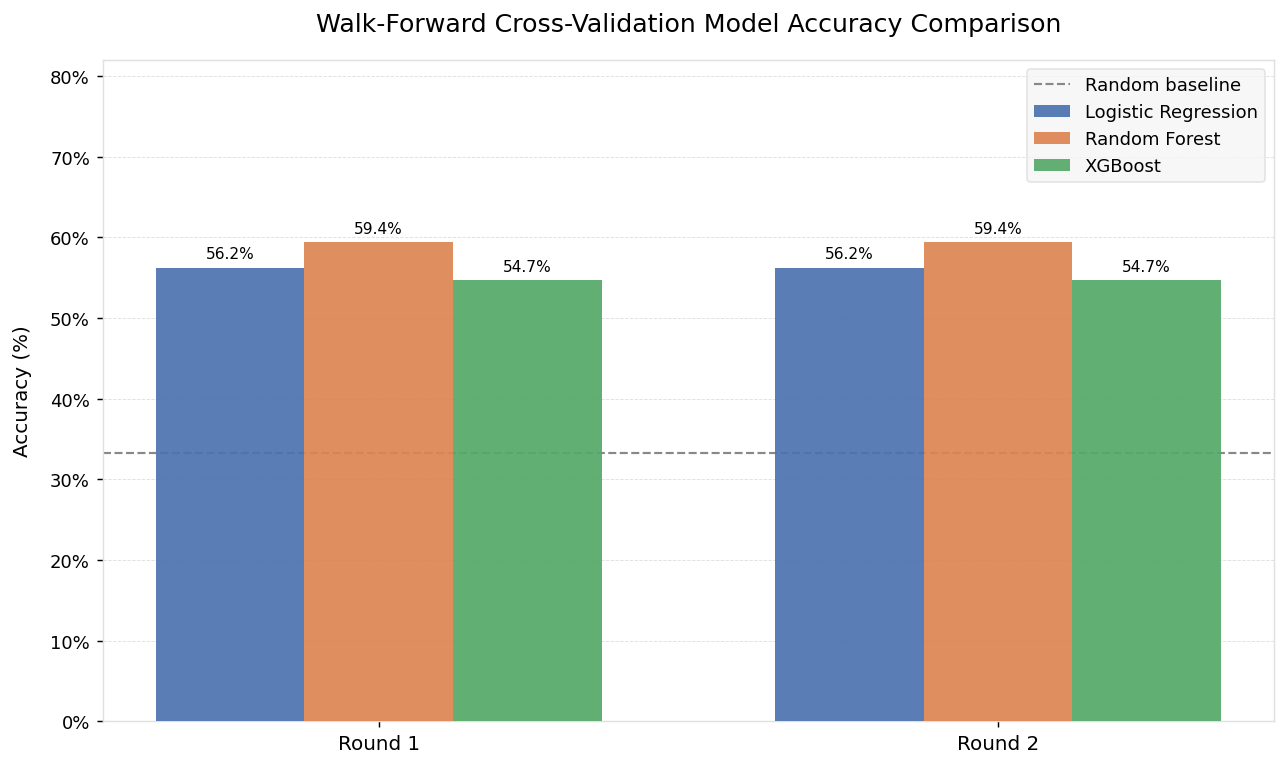

In [67]:
# Walk-forward cross-validation bar chart
PALETTE = {
    'Logistic Regression': '#4C72B0',
    'Random Forest':       '#DD8452',
    'XGBoost':             '#55A868',
}
BG, FG, GRID, ACCENT = '#FFFFFF', '#000000', '#E0E0E0', '#FFB800'

with plt.style.context('default'):
    fig, ax = plt.subplots(figsize=(10, 6), dpi=130)
    fig.patch.set_facecolor(BG)
    ax.set_facecolor(BG)
    for spine in ax.spines.values(): spine.set_edgecolor(GRID)

    x, width = np.arange(2), 0.24
    labels = ['Round 1', 'Round 2']

    for i, (mname, _) in enumerate(models_cfg):
        bars = ax.bar(x + (i-1)*width, [v*100 for v in wf_table[mname]],
                      width, label=mname, color=PALETTE[mname],
                      edgecolor='none', zorder=3, alpha=0.92)
        for bar in bars:
            h = bar.get_height()
            ax.text(bar.get_x()+bar.get_width()/2, h+0.8, f'{h:.1f}%',
                    ha='center', va='bottom', fontsize=8.5, color=FG)

    ax.axhline(33.3, color='#888', linestyle='--', linewidth=1.2,
               label='Random baseline', zorder=2)
    ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=11, color=FG)
    ax.set_ylabel('Accuracy (%)', fontsize=11, labelpad=10, color=FG)
    ax.set_ylim(0, 82)
    ax.yaxis.set_major_formatter(mtick.FormatStrFormatter('%.0f%%'))
    ax.set_title('Walk-Forward Cross-Validation Model Accuracy Comparison',
                 fontsize=14, color=FG, pad=16)
    ax.grid(axis='y', linestyle='--', linewidth=0.5, color=GRID, zorder=0)
    ax.tick_params(colors=FG)
    leg = ax.legend(fontsize=10, framealpha=0.8, loc='upper right',
                    facecolor='#F5F5F5', edgecolor=GRID)
    for t in leg.get_texts(): t.set_color(FG)
    plt.tight_layout()
    plt.show()


### 10. Final Model: Trained on All Available Data

Walk forward cross validation identified the best model and the tuned weights.
That model is now trained on the full historical dataset (World Cup matches plus
qualifiers). The WC2026 group stage itself is not used for training; it only
feeds the dynamic Elo ratings and the rolling form features.


In [60]:
final_mask = m18 | m22 | mQual
X_final    = X_all[final_mask].values
y_final    = y_all[final_mask].values
w_final    = make_weights(final_mask, W18, W22)

final_scaler = StandardScaler()
X_final_s    = final_scaler.fit_transform(X_final)

# Train all three models on the full training set
final_lr = LogisticRegression(max_iter=1000, C=0.5, random_state=42)
final_lr.fit(X_final_s, y_final, sample_weight=w_final)

final_rf = RandomForestClassifier(n_estimators=200, max_depth=5, random_state=42, n_jobs=-1)
final_rf.fit(X_final, y_final, sample_weight=w_final)

final_xgb = XGBClassifier(n_estimators=200, max_depth=3, learning_rate=0.05,
                            subsample=0.8, colsample_bytree=0.8,
                            eval_metric='mlogloss', random_state=42, verbosity=0)
final_xgb.fit(X_final, y_final, sample_weight=w_final)

best_needs_scale = (best_model_name == 'Logistic Regression')
best_obj         = {'Logistic Regression': final_lr,
                    'Random Forest':       final_rf,
                    'XGBoost':             final_xgb}[best_model_name]

n_total = final_mask.sum()
print(f"Final training set: {n_total} matches")
print()
print(f"  WC2018 (w={W18}): {m18[final_mask].sum()}")
print(f"  WC2022 (w={W22}): {m22[final_mask].sum()}")
print(f"  WC2026 (w=1.0): {m26[final_mask].sum()}")
print(f"  Qualifiers (w={QUAL_W}): {mQual[final_mask].sum()}")
print(f"\nFinal model: {best_model_name}")


Final training set: 1017 matches

  WC2018 (w=1.0): 64
  WC2022 (w=1.0): 64
  WC2026 (w=1.0): 0
  Qualifiers (w=0.5): 889

Final model: Random Forest


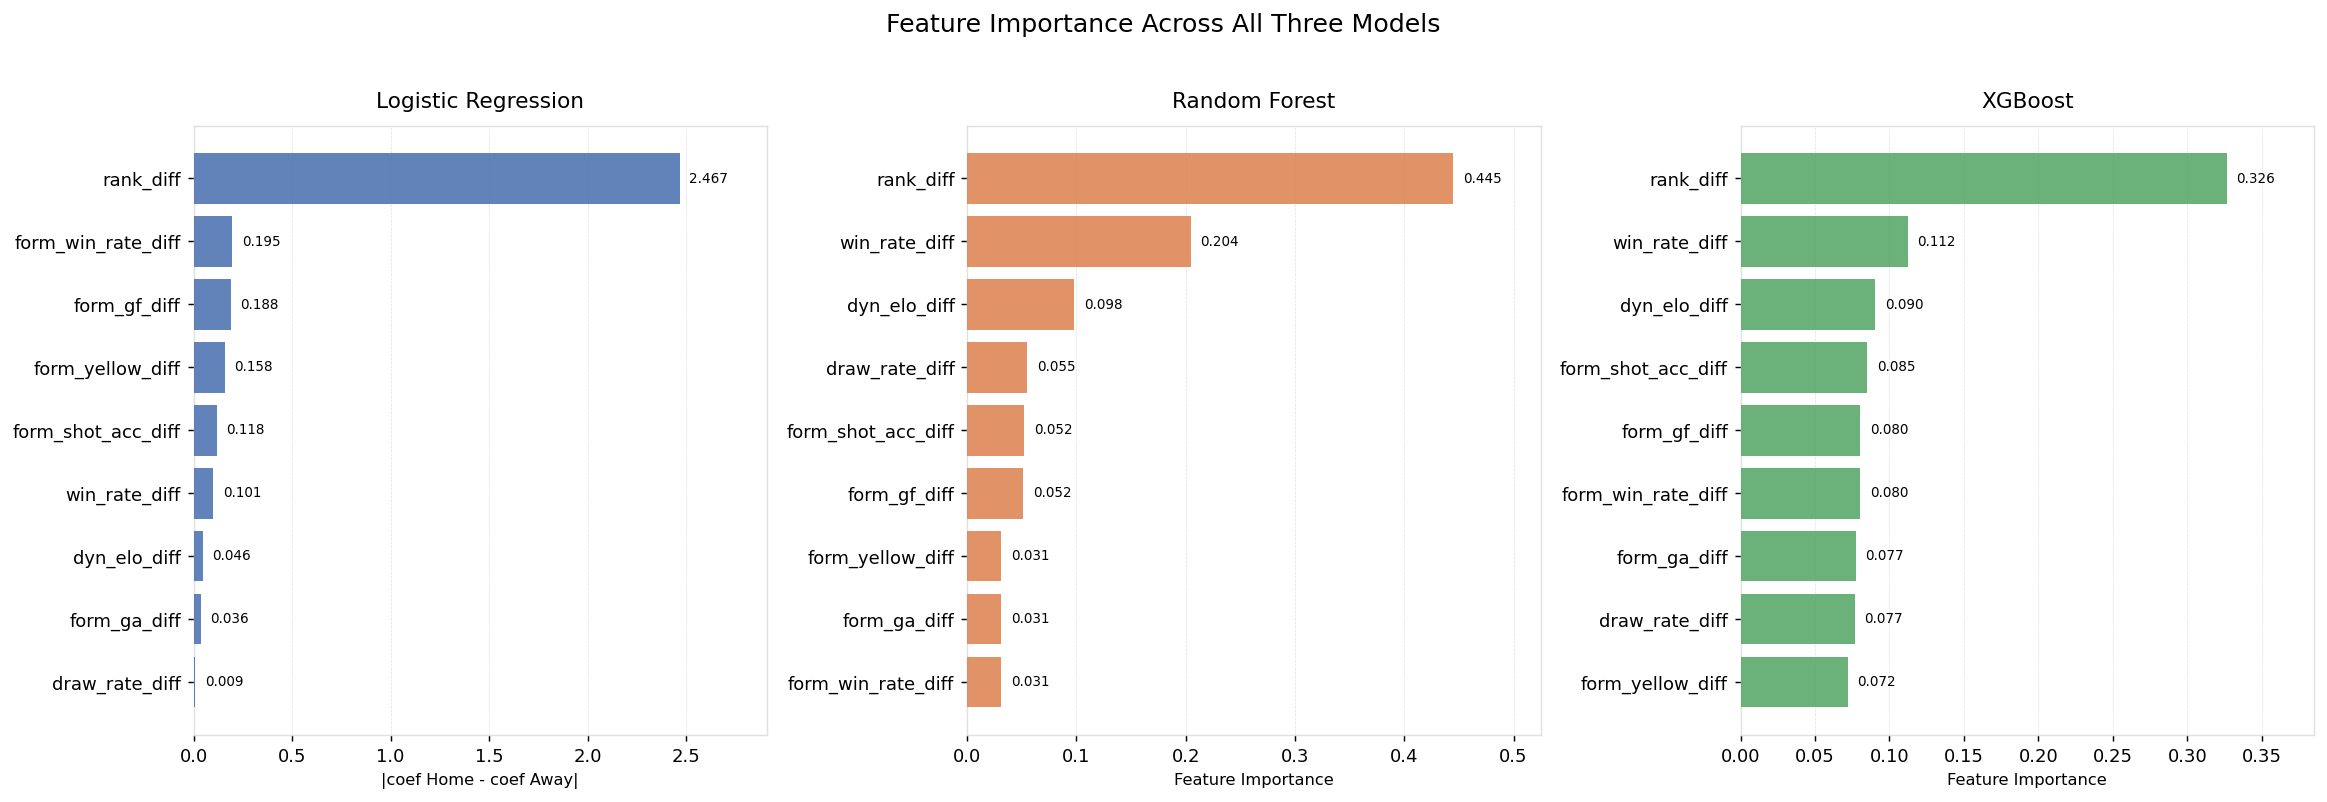

In [61]:
with plt.style.context('default'):
    fig, axes = plt.subplots(1, 3, figsize=(18, 6), dpi=130)
    fig.patch.set_facecolor(BG)

    coef_diff = np.abs(final_lr.coef_[0] - final_lr.coef_[2])
    lr_ser    = pd.Series(coef_diff,                        index=FEATURE_NAMES).sort_values()
    rf_ser    = pd.Series(final_rf.feature_importances_,   index=FEATURE_NAMES).sort_values()
    xgb_ser   = pd.Series(final_xgb.feature_importances_,  index=FEATURE_NAMES).sort_values()

    for ax, ser, title, xlabel, color in [
        (axes[0], lr_ser,  'Logistic Regression', '|coef Home - coef Away|', PALETTE['Logistic Regression']),
        (axes[1], rf_ser,  'Random Forest',        'Feature Importance',       PALETTE['Random Forest']),
        (axes[2], xgb_ser, 'XGBoost',              'Feature Importance',       PALETTE['XGBoost']),
    ]:
        ax.set_facecolor(BG)
        for spine in ax.spines.values(): spine.set_edgecolor(GRID)
        ax.barh(ser.index, ser.values, color=color, alpha=0.88, edgecolor='none', zorder=3)
        ax.set_xlabel(xlabel, fontsize=9, color=FG)
        ax.grid(axis='x', linestyle='--', linewidth=0.4, color=GRID, zorder=0)
        ax.set_axisbelow(True)
        ax.set_title(title, fontsize=12, color=FG, pad=10)
        ax.tick_params(colors=FG)
        for bar in ax.patches:
            w = bar.get_width()
            ax.text(w + ser.max()*0.02, bar.get_y()+bar.get_height()/2,
                    f'{w:.3f}', va='center', fontsize=7.5, color=FG)
        ax.set_xlim(0, ser.max() * 1.18)

    fig.suptitle('Feature Importance Across All Three Models', fontsize=14, color=FG, y=1.02)
    plt.tight_layout()
    plt.show()


### 11. predict_match() -- Predict Any Two Teams

In [62]:
def predict_match(team_a, team_b, verbose=True):

    """
    Predict a match on neutral ground.
    To eliminate home/away ordering bias, the raw model output is averaged
    from both orderings (A vs B) and (B vs A), then re-normalised.
    This ensures predict_match(A,B) == predict_match(B,A) (swapped).
    """

    def raw_probs(home, away):
        ha  = dynamic_elo.get(home, 1500)
        aa  = dynamic_elo.get(away, 1500)
        hs  = get_static(home);  as_ = get_static(away)
        hf  = latest_form_per_team.get(home, DEFAULTS_FORM)
        af  = latest_form_per_team.get(away, DEFAULTS_FORM)
        feat = np.array([[
            ha - aa,
            hs['win_rate']            - as_['win_rate'],
            hs['draw_rate']           - as_['draw_rate'],
            as_['rank']               - hs['rank'],
            hf['form_win_rate']       - af['form_win_rate'],
            hf['form_goals_scored']   - af['form_goals_scored'],
            hf['form_goals_conceded'] - af['form_goals_conceded'],
            hf['form_shot_acc']       - af['form_shot_acc'],
            hf['form_yellows']        - af['form_yellows'],
        ]])
        feat_in = final_scaler.transform(feat) if best_needs_scale else feat
        return best_obj.predict_proba(feat_in)[0]   # [win, draw, loss]

    # Forward:  A=home, B=away  -> [p(A wins), p(draw), p(B wins)]
    p_fwd = raw_probs(team_a, team_b)

    # Reverse:  B=home, A=away  -> [p(B wins), p(draw), p(A wins)]
    p_rev = raw_probs(team_b, team_a)

    # Average, keeping A/B semantics: A_win, draw, B_win
    a_win = (p_fwd[0] + p_rev[2]) / 2
    draw  = (p_fwd[1] + p_rev[1]) / 2
    b_win = (p_fwd[2] + p_rev[0]) / 2

    # Re-normalise (sum should already be ~1, but guard floating point)
    total = a_win + draw + b_win
    a_win, draw, b_win = a_win/total, draw/total, b_win/total

    if verbose:
        print(f"\n  {team_a} vs {team_b}")
        print(f"  Elo rating: {dynamic_elo.get(team_a,1500):.0f} vs {dynamic_elo.get(team_b,1500):.0f}\n")

        for label, p in zip([f'{team_a} Win','Draw',f'{team_b} Win'], [a_win,draw,b_win]):
            print(f"  {label:<26} {p:5.1%}  {'█'*int(p*30)}")
        print(f"\n  Predicted winner: {team_a if a_win>b_win else team_b}\n")

    return a_win, draw, b_win


In [63]:
predict_match("Argentina", "Algeria")


  Argentina vs Algeria
  Elo rating: 1828 vs 1647

  Argentina Win              57.4%  █████████████████
  Draw                       26.5%  ███████
  Algeria Win                16.0%  ████

  Predicted winner: Argentina



(np.float64(0.5744053534907027),
 np.float64(0.26547873005299094),
 np.float64(0.16011591645630646))

In [64]:
predict_match("Haiti","Morocco")



  Haiti vs Morocco
  Elo rating: 1500 vs 1723

  Haiti Win                   9.2%  ██
  Draw                       19.2%  █████
  Morocco Win                71.6%  █████████████████████

  Predicted winner: Morocco



(np.float64(0.09219251328474444),
 np.float64(0.19157178096179062),
 np.float64(0.7162357057534648))

In [65]:
predict_match("Portugal", "Uzbekistan")


  Portugal vs Uzbekistan
  Elo rating: 1680 vs 1502

  Portugal Win               60.4%  ██████████████████
  Draw                       26.9%  ████████
  Uzbekistan Win             12.6%  ███

  Predicted winner: Portugal



(np.float64(0.6044979570603859),
 np.float64(0.2691586630032955),
 np.float64(0.12634337993631872))

### 12. World Cup 2026 Bracket Setup

Three teams qualify from each group (36 total), and the eight best third place
teams advance to reach 32 teams. The bracket slots are fixed by FIFA, so teams
cannot meet before the round the draw assigns them to. Where the best third
place teams sit in the bracket depends on which groups they came from; this is
encoded below.


In [66]:
# Round of 32 bracket

# R32 -> R16 bracket path:
#   R16-A : M1w vs M2w   QF-1-upper : R16-A vs R16-B   SF-1 : QF-1 vs QF-2
#   R16-B : M3w vs M4w   QF-1-lower : R16-C vs R16-D   SF-2 : QF-3 vs QF-4
#   R16-C : M5w vs M6w   QF-2-upper : R16-E vs R16-F
#   R16-D : M7w vs M8w   QF-2-lower : R16-G vs R16-H
#   R16-E : M9w vs M10w
#   R16-F : M11w vs M12w
#   R16-G : M13w vs M14w
#   R16-H : M15w vs M16w

r32 = [
    # (team_a,            team_b,                  R16_slot)
    ("South Africa",      "Canada",                "R16-A"),   # M1
    ("Brazil",            "Japan",                 "R16-A"),   # M2
    ("Germany",           "Paraguay",              "R16-B"),   # M3
    ("Netherlands",       "Morocco",               "R16-B"),   # M4
    ("Ivory Coast",       "Norway",                "R16-C"),   # M5
    ("France",            "Sweden",                "R16-C"),   # M6
    ("Mexico",            "Ecuador",               "R16-D"),   # M7
    ("England",           "D.R. Congo",            "R16-D"),   # M8
    ("Belgium",           "Senegal",               "R16-E"),   # M9
    ("United States",     "Bosnia and Herzegovina","R16-E"),   # M10
    ("Spain",             "Austria",               "R16-F"),   # M11
    ("Portugal",          "Croatia",               "R16-F"),   # M12
    ("Switzerland",       "Algeria",               "R16-G"),   # M13
    ("Australia",         "Egypt",                 "R16-G"),   # M14
    ("Argentina",         "Cape Verde",            "R16-H"),   # M15
    ("Colombia",          "Ghana",                 "R16-H"),   # M16
]

print("\nR32 bracket:")
print(f"{'M#':>3}  {'Home':<26} {'Away':<26} {'R16 Slot'}")
for i, (a, b, slot) in enumerate(r32, 1):
    print(f"M{i:>2}  {a:<26} {b:<26} {slot}")



R32 bracket:
 M#  Home                       Away                       R16 Slot
M 1  South Africa               Canada                     R16-A
M 2  Brazil                     Japan                      R16-A
M 3  Germany                    Paraguay                   R16-B
M 4  Netherlands                Morocco                    R16-B
M 5  Ivory Coast                Norway                     R16-C
M 6  France                     Sweden                     R16-C
M 7  Mexico                     Ecuador                    R16-D
M 8  England                    D.R. Congo                 R16-D
M 9  Belgium                    Senegal                    R16-E
M10  United States              Bosnia and Herzegovina     R16-E
M11  Spain                      Austria                    R16-F
M12  Portugal                   Croatia                    R16-F
M13  Switzerland                Algeria                    R16-G
M14  Australia                  Egypt                      R16-G
M15  Arg

### 13. Monte Carlo Bracket Simulation

This section uses a Numba accelerated simulation to estimate each team's
probability of winning the tournament.

How it works:
1. predict_match() computes a win probability for every possible matchup and
   stores the results in a lookup matrix
2. A Numba compiled function runs a large number of full tournament
   simulations using that matrix, with no Python overhead in the inner loop
3. The bracket follows the real FIFA 2026 structure, so teams advance along
   the correct paths

Each simulation plays:
1. 16 Round of 32 matches, producing 16 winners
2. 8 Round of 16 matches, producing 8 winners
3. 4 Quarter finals, producing 4 winners
4. 2 Semi finals, producing 2 winners
5. 1 Final, producing the champion


In [47]:
# Build list of 32 teams in bracket order (matches M1..M16, each contributing 2 teams)
bracket_teams = []
for a, b, *_ in r32:
    bracket_teams.append(a)
    bracket_teams.append(b)

N = len(bracket_teams)   # 32
team_idx = {t: i for i, t in enumerate(bracket_teams)}

# r16[k] holds the winner of match Mk+1 (bracket_teams indices k*2, k*2+1):
#   r16[0]=M1w  r16[1]=M2w  r16[2]=M3w  r16[3]=M4w
#   r16[4]=M5w  r16[5]=M6w  r16[6]=M7w  r16[7]=M8w
#   r16[8]=M9w  r16[9]=M10w r16[10]=M11w r16[11]=M12w
#   r16[12]=M13w r16[13]=M14w r16[14]=M15w r16[15]=M16w
#
# Official FIFA R16 pairings:
#   R16-M89: M3w  vs M6w  -> r16[2]  vs r16[5]
#   R16-M90: M1w  vs M4w  -> r16[0]  vs r16[3]
#   R16-M91: M2w  vs M5w  -> r16[1]  vs r16[4]
#   R16-M92: M7w  vs M8w  -> r16[6]  vs r16[7]
#   R16-M93: M12w vs M11w -> r16[11] vs r16[10]
#   R16-M94: M10w vs M9w  -> r16[9]  vs r16[8]
#   R16-M95: M15w vs M14w -> r16[14] vs r16[13]
#   R16-M96: M13w vs M16w -> r16[12] vs r16[15]
#
# QF pairings:
#   QF-M97:  M89w vs M90w -> qf[0] vs qf[1]
#   QF-M98:  M93w vs M94w -> qf[4] vs qf[5]
#   QF-M99:  M91w vs M92w -> qf[2] vs qf[3]
#   QF-M100: M95w vs M96w -> qf[6] vs qf[7]
# where qf = [M89w, M90w, M91w, M92w, M93w, M94w, M95w, M96w]
#
# SF pairings:
#   SF-M101: M97w vs M98w  -> sf[0] vs sf[1]
#   SF-M102: M99w vs M100w -> sf[2] vs sf[3]

# Hardcode the exact R16 bracket as pairs of r16 indices (official FIFA order)
R16_PAIRS = [(2,5), (0,3), (1,4), (6,7), (11,10), (9,8), (14,13), (12,15)]
# qf array will be [M89w, M90w, M91w, M92w, M93w, M94w, M95w, M96w]
QF_PAIRS  = [(0,1), (4,5), (2,3), (6,7)]
# sf array will be [M97w, M98w, M99w, M100w]

# Pre-compute win probability matrix P[i,j] = P(team i beats team j)
print("Pre-computing win probability matrix...")
P = np.full((N, N), 0.5)
for i, ta in enumerate(bracket_teams):
    for j, tb in enumerate(bracket_teams):
        if i != j:
            hw, _, aw = predict_match(ta, tb, verbose=False)
            P[i, j] = hw + (1 - hw - aw) * 0.5
print(f"Matrix ready: {N}x{N}")

# Numba compiled simulation
@njit
def run_simulations(P, r16_pairs, qf_pairs, n_sims, seed=42):

    """
    Simulate the bracket n_sims times using the exact FIFA bracket wiring.
    r16_pairs: 8x2 array of r16-index pairs for the 8 R16 matches.
    qf_pairs:  4x2 array of qf-index pairs for the 4 QF matches.
    SF: qf[0]w vs qf[1]w (SF1), qf[2]w vs qf[3]w (SF2).
    Final: SF1w vs SF2w.
    """

    np.random.seed(seed)
    N    = P.shape[0]
    wins = np.zeros(N, dtype=np.int64)

    for _ in range(n_sims):
        # Round of 32 (16 matches, consecutive pairs from bracket_teams)
        r16 = np.empty(16, dtype=np.int64)
        for m in range(16):
            a = m * 2
            b = m * 2 + 1
            r16[m] = a if np.random.random() < P[a, b] else b

        # Round of 16
        qf = np.empty(8, dtype=np.int64)
        for m in range(8):
            ia, ib = r16_pairs[m, 0], r16_pairs[m, 1]
            a, b = r16[ia], r16[ib]
            qf[m] = a if np.random.random() < P[a, b] else b

        # Quarter-finals
        sf = np.empty(4, dtype=np.int64)
        for m in range(4):
            ia, ib = qf_pairs[m, 0], qf_pairs[m, 1]
            a, b = qf[ia], qf[ib]
            sf[m] = a if np.random.random() < P[a, b] else b

        # Semi-finals
        fin = np.empty(2, dtype=np.int64)
        a, b = sf[0], sf[1]
        fin[0] = a if np.random.random() < P[a, b] else b
        a, b = sf[2], sf[3]
        fin[1] = a if np.random.random() < P[a, b] else b

        # Final
        champ = fin[0] if np.random.random() < P[fin[0], fin[1]] else fin[1]
        wins[champ] += 1

    return wins

r16_pairs_np = np.array(R16_PAIRS, dtype=np.int64)
qf_pairs_np  = np.array(QF_PAIRS,  dtype=np.int64)

# Warm-up compile
_ = run_simulations(P, r16_pairs_np, qf_pairs_np, 10)

# Timed run
N_SIMS = 500_000
t0     = time.time()
win_counts = run_simulations(P, r16_pairs_np, qf_pairs_np, N_SIMS)
elapsed    = time.time() - t0

win_probs = {bracket_teams[i]: win_counts[i]/N_SIMS for i in range(N)}
win_probs = dict(sorted(win_probs.items(), key=lambda x: x[1], reverse=True))

print(f"\n{N_SIMS:,} simulations in {elapsed:.3f}s ({N_SIMS/elapsed:,.0f} sims/sec)")


Pre-computing win probability matrix...
Matrix ready: 32x32

500,000 simulations in 0.196s (2,556,994 sims/sec)


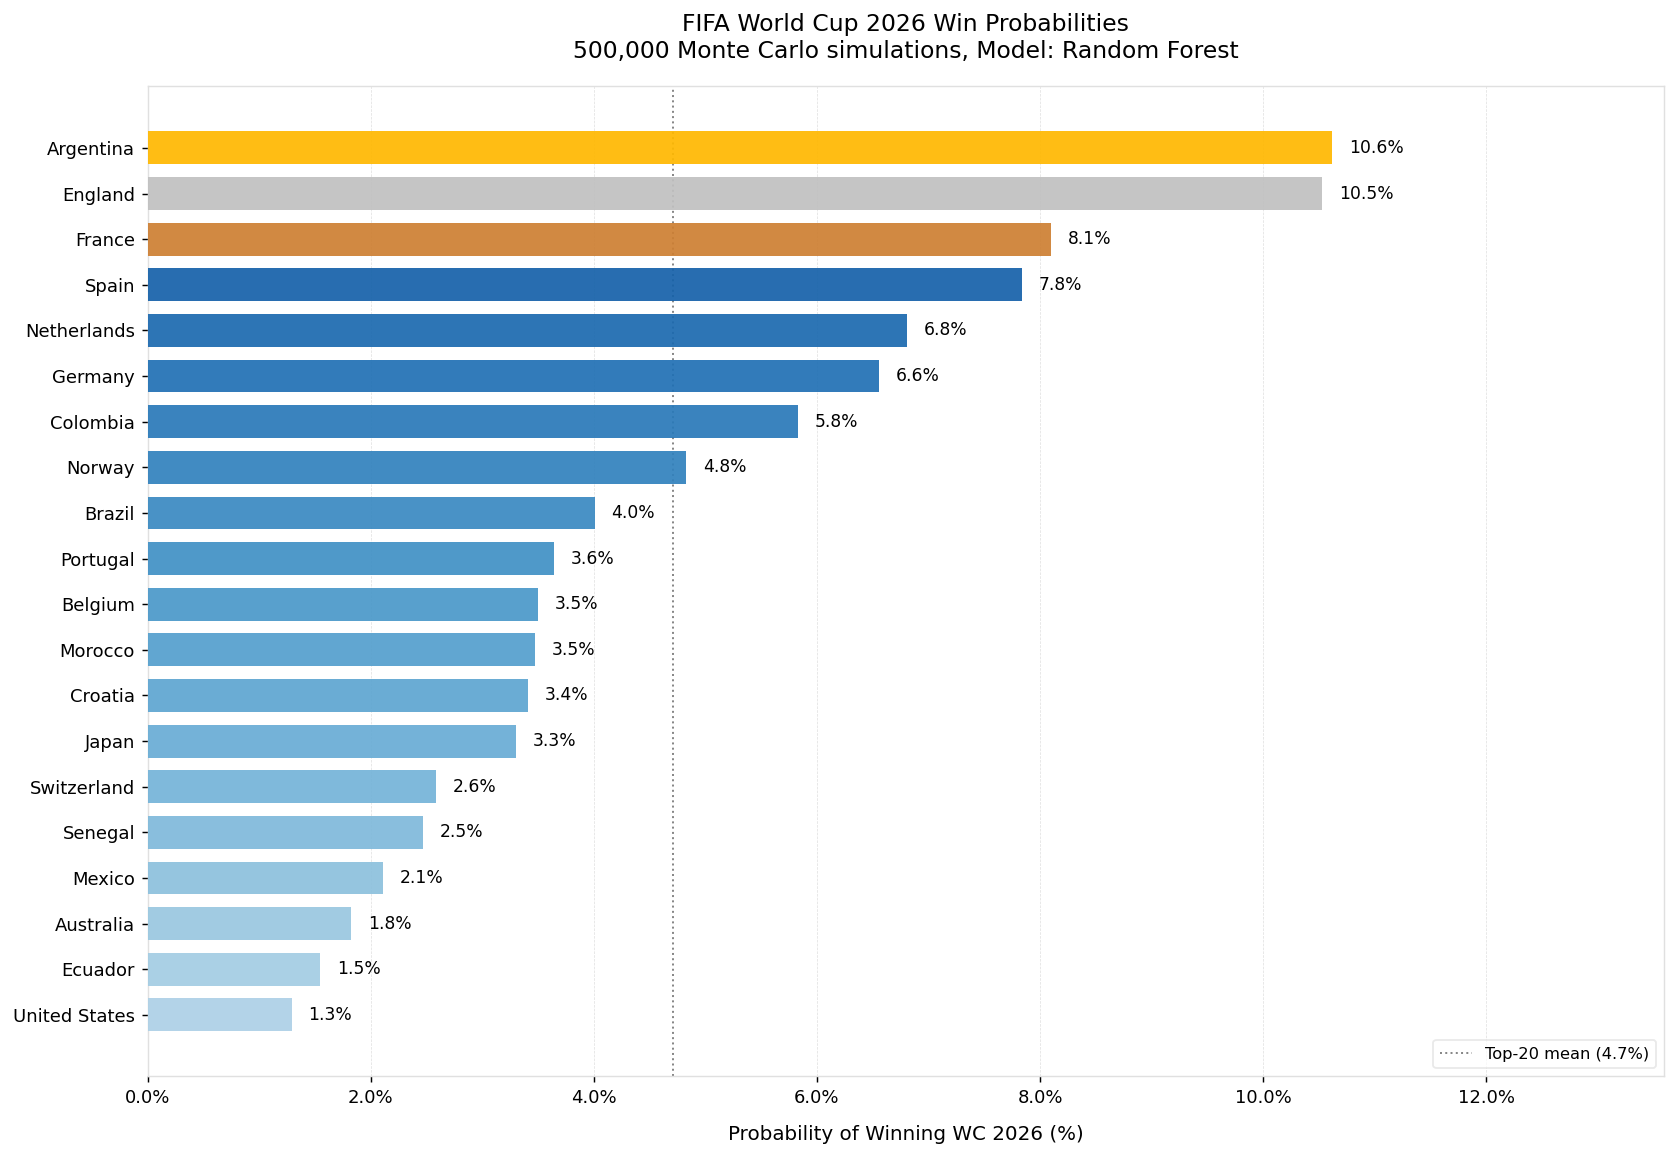


World Cup 2026 Win Probability Rankings
  #    Team                              Win%     Elo
  1.  Argentina                       10.62%    1828
  2.  England                         10.53%    1818
  3.  France                           8.10%    1936
   4.  Spain                            7.84%    1732
   5.  Netherlands                      6.81%    1849
   6.  Germany                          6.55%    1735
   7.  Colombia                         5.83%    1723
   8.  Norway                           4.83%    1746
   9.  Brazil                           4.01%    1668
  10.  Portugal                         3.64%    1680
  11.  Belgium                          3.50%    1751
  12.  Morocco                          3.47%    1723
  13.  Croatia                          3.41%    1746
  14.  Japan                            3.30%    1778
  15.  Switzerland                      2.59%    1647
  16.  Senegal                          2.46%    1688
  17.  Mexico                           2.11

In [48]:
# Win probability bar chart
top_n      = 20
top_items  = list(win_probs.items())[:top_n]
teams_plot = [t for t, _ in top_items]
probs_plot = [p for _, p in top_items]
medal_colors = {0: ACCENT, 1: '#C0C0C0', 2: '#CD7F32'}
bar_colors   = [medal_colors.get(i, plt.cm.Blues(0.9 - (i/top_n)*0.6)) for i in range(top_n)]

with plt.style.context('default'):
    fig, ax = plt.subplots(figsize=(13, 9), dpi=130)
    for spine in ax.spines.values(): spine.set_edgecolor('#E0E0E0')

    bars = ax.barh(teams_plot[::-1], [p*100 for p in probs_plot[::-1]],
                   color=bar_colors[::-1], edgecolor='none', zorder=3, alpha=0.92, height=0.72)
    for bar, prob in zip(bars, probs_plot[::-1]):
        ax.text(bar.get_width()+0.15, bar.get_y()+bar.get_height()/2,
                f'{prob:.1%}', va='center', fontsize=9.5, color='black')

    mean_p = np.mean(probs_plot)*100
    ax.axvline(mean_p, color='#888', linestyle=':', linewidth=1.1,
               label=f'Top-20 mean ({mean_p:.1f}%)', zorder=2)
    ax.set_xlabel('Probability of Winning WC 2026 (%)', fontsize=11, labelpad=10, color='black')
    ax.set_title(
        f'FIFA World Cup 2026 Win Probabilities\n'
        f'{N_SIMS:,} Monte Carlo simulations, Model: {best_model_name}',
        fontsize=13, color='black', pad=16)
    ax.xaxis.set_major_formatter(mtick.FormatStrFormatter('%.1f%%'))
    ax.set_xlim(0, max(probs_plot)*100*1.28)
    ax.grid(axis='x', linestyle='--', linewidth=0.4, color='#E0E0E0', zorder=0)
    ax.tick_params(colors='black')
    leg = ax.legend(fontsize=9, framealpha=0.7, loc='lower right',
                    facecolor='white', edgecolor='#E0E0E0')
    for t in leg.get_texts(): t.set_color('black')
    plt.tight_layout(); plt.show()

# Win probability rankings
print("\nWorld Cup 2026 Win Probability Rankings")
print(f"  {'#':<3}  {'Team':<30} {'Win%':>7}  {'Elo':>6}")
for rank, (team, prob) in enumerate(win_probs.items(), 1):
    elo   = dynamic_elo.get(team, 1500)
    medal = "1." if rank==1 else "2." if rank==2 else "3." if rank==3 else f"{rank:>2}."
    print(f"  {medal}  {team:<30} {prob:>7.2%}  {elo:>6.0f}")


### 14. Predicted Tournament Results: R32 to Final

This section uses the most likely winner of each match (the higher probability
outcome) to project the full bracket as a single deterministic path, rather
than a simulation average.


In [49]:
def predict_winner(team_a, team_b):
    hw, dw, aw = predict_match(team_a, team_b, verbose=False)
    pa = hw + dw * 0.5
    return (team_a, pa) if pa >= 0.5 else (team_b, 1 - pa)

def print_round(title, fixtures):
    print(f"\n{title}")
    print("=" * len(title))
    winners = []
    for a, b in fixtures:
        winner, prob = predict_winner(a, b)
        print(f"  {a:<28} vs  {b}")
        print(f"  Winner: {winner} ({prob:.0%})\n")
        winners.append(winner)
    return winners

# Round of 32
r32_fixtures = [(a, b) for a, b, *_ in r32]
r16q = print_round("ROUND OF 32", r32_fixtures)
# r16q[k] = winner of match Mk+1

# Round of 16 -- exact FIFA bracket wiring
r16_fixtures = [(r16q[ia], r16q[ib]) for ia, ib in R16_PAIRS]
qfw = print_round("ROUND OF 16", r16_fixtures)
# qfw[m] = winner of R16 match m

# Quarter-finals -- exact FIFA bracket wiring
qf_fixtures = [(qfw[ia], qfw[ib]) for ia, ib in QF_PAIRS]
sfw = print_round("QUARTER-FINALS", qf_fixtures)

# Semi-finals
sf_fixtures = [(sfw[0], sfw[1]), (sfw[2], sfw[3])]
finalists   = print_round("SEMI-FINALS", sf_fixtures)

# Final
print(f"\nFINALS")
print("=" * 5)
champion, prob = predict_winner(finalists[0], finalists[1])
runner_up      = finalists[1] if champion == finalists[0] else finalists[0]
print(f"  {finalists[0]:<28} vs  {finalists[1]}")
print(f"\n  World Champion: {champion} ({prob:.0%} win probability)")
print(f"  Runner-up: {runner_up}")



ROUND OF 32
  South Africa                 vs  Canada
  Winner: Canada (59%)

  Brazil                       vs  Japan
  Winner: Japan (50%)

  Germany                      vs  Paraguay
  Winner: Germany (65%)

  Netherlands                  vs  Morocco
  Winner: Netherlands (57%)

  Ivory Coast                  vs  Norway
  Winner: Norway (64%)

  France                       vs  Sweden
  Winner: France (69%)

  Mexico                       vs  Ecuador
  Winner: Mexico (51%)

  England                      vs  D.R. Congo
  Winner: England (88%)

  Belgium                      vs  Senegal
  Winner: Belgium (54%)

  United States                vs  Bosnia and Herzegovina
  Winner: United States (75%)

  Spain                        vs  Austria
  Winner: Spain (68%)

  Portugal                     vs  Croatia
  Winner: Croatia (50%)

  Switzerland                  vs  Algeria
  Winner: Switzerland (53%)

  Australia                    vs  Egypt
  Winner: Australia (55%)

  Argentina    

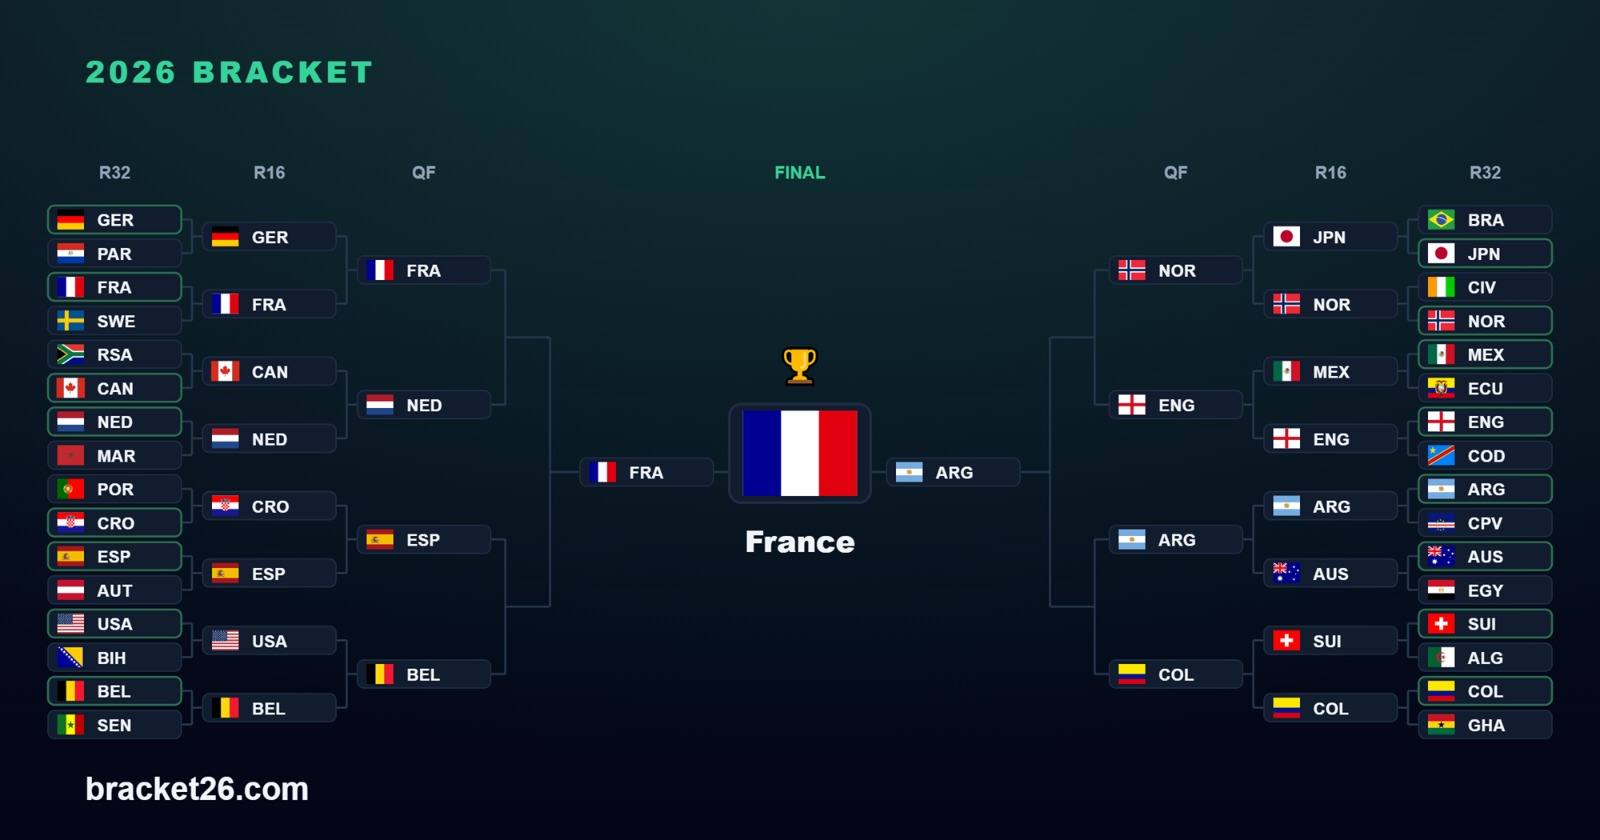